In [ ]:
import torch
import numpy as np
from tqdm.auto import tqdm
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, Subset
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Number of total classes: 15
Tomato_Bacterial_spot
256
256


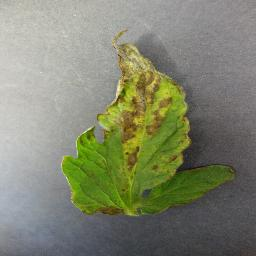

In [ ]:
path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"

classes = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(f"Number of total classes: {len(classes)}")
print(class_name)
print(img.height)
print(img.width)

img


In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor()
])

In [ ]:
def visualize_transform(img_path, transform):
    img = Image.open(img_path)
    print(img)
    transformed_img = transform(img)
    print(transformed_img)

    if isinstance(transformed_img, torch.Tensor):
        transformed_img = transforms.ToPILImage()(transformed_img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(transformed_img)
    axes[1].set_title("Transformed")
    axes[1].axis("off")

    plt.show()

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x784AC6169E50>
tensor([[[0.4314, 0.4118, 0.4196,  ..., 0.4196, 0.4235, 0.4353],
         [0.4627, 0.4510, 0.4510,  ..., 0.4431, 0.4549, 0.4627],
         [0.4627, 0.4588, 0.4588,  ..., 0.4118, 0.4039, 0.4000],
         ...,
         [0.3725, 0.3725, 0.3725,  ..., 0.2196, 0.2235, 0.2275],
         [0.3608, 0.3647, 0.3725,  ..., 0.2157, 0.2157, 0.2275],
         [0.3569, 0.3686, 0.3804,  ..., 0.2039, 0.2157, 0.2353]],

        [[0.4118, 0.3922, 0.4000,  ..., 0.3882, 0.3922, 0.4039],
         [0.4431, 0.4314, 0.4314,  ..., 0.4118, 0.4235, 0.4314],
         [0.4431, 0.4392, 0.4392,  ..., 0.3804, 0.3725, 0.3686],
         ...,
         [0.3373, 0.3373, 0.3373,  ..., 0.1843, 0.1882, 0.1922],
         [0.3255, 0.3294, 0.3373,  ..., 0.1804, 0.1804, 0.1922],
         [0.3216, 0.3333, 0.3451,  ..., 0.1686, 0.1804, 0.2000]],

        [[0.5020, 0.4824, 0.4902,  ..., 0.4706, 0.4745, 0.4863],
         [0.5333, 0.5216, 0.5216,  ..., 0

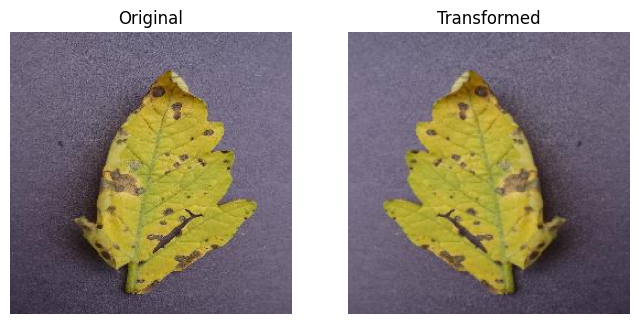

In [ ]:
class_name = random.choice(classes)
class_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

visualize_transform(img_path, data_transform)

In [ ]:
full_dataset = datasets.ImageFolder(root=path, transform=None)
full_dataset

class_to_idx = full_dataset.class_to_idx
idx_to_class = {value: key for key, value in class_to_idx.items()}
classes = list(class_to_idx.keys())

In [ ]:
targets = [sample[1] for sample in full_dataset.samples]

train_idx, test_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

In [ ]:
print(f"Number of Train images: {len(train_idx)} | Number of Test images: {len(test_idx)}")

Number of Train images: 16147 | Number of Test images: 4037


In [ ]:
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

temp_full = datasets.ImageFolder(root=path, transform=temp_transform)
temp_train = Subset(temp_full, train_idx)

In [ ]:
def get_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
  rgb_sum = torch.zeros(3)
  rgb_sumsq = torch.zeros(3)
  count_pixels = 0

  for x, _ in loader:
    b, c, h, w = x.shape
    count_pixels += b * h * w
    rgb_sum += x.sum(dim=[0, 2, 3])
    rgb_sumsq += (x**2).sum(dim=[0, 2, 3])

  mean = rgb_sum / count_pixels
  std = torch.sqrt(rgb_sumsq / count_pixels - mean **2)
  return mean, std

In [ ]:
# mean_tensor, std_tensor = get_mean_std(temp_train)
# mean = mean_tensor.list()
# std = std_tensor.list()

In [ ]:
mean = [0.4592542350292206, 0.4754604697227478, 0.4115070700645447]
std = [0.1860169768333435, 0.16259966790676117, 0.20085515081882477]

In [ ]:
# mean = [0.5, 0.5, 0.5]
# std = [0.5, 0.5, 0.5]
# mean,std= get_mean_std(temp_train)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
train_data_all = datasets.ImageFolder(root=path, transform=train_transform)
test_data_all = datasets.ImageFolder(root=path, transform=test_transform)

train_set = Subset(train_data_all,train_idx)
test_set = Subset(test_data_all,test_idx)

In [ ]:
len(train_set), len( test_set)

(16147, 4037)

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
len(train_loader), len(test_loader)

(1010, 253)

In [ ]:
class SampleCNN(nn.Module):
  def __init__(self, input_shape, output_shape, hidden_units):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer(x)

In [ ]:
input_shape = 3*224*224
output_shape = 15
hidden_units = 256

sampleCnn = SampleCNN(input_shape, output_shape, hidden_units)

In [ ]:
sampleCnn

SampleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=15, bias=True)
  )
)

In [ ]:
class newCNN(nn.Module):
  def __init__(self, num_classes):
    super.__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*28*28, out_features=512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=512, out_features=num_classes)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.classifier(x)
    return x
    # return self.classifier(self.block3(self.block2(self.block1(x))))

In [ ]:
mlp_model= sampleCnn

In [ ]:
#Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

#Move model to GPU if available
mlp_model = mlp_model.to(device)

# Training and Evaluation Loop
EPOCHS = 10

for epoch in range(EPOCHS):

  # Training Phase
  mlp_model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  # tqdm progress bar
  for batch_idx, (X_batch, y_batch) in enumerate (tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    #forward pass
    y_pred = mlp_model(X_batch)
    loss = loss_fn(y_pred, y_batch)

    #backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #running metrics
    running_loss += loss.item()
    _, predicted = torch.max(y_pred, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

    #batch-wise loss print every 50 batches
    if batch_idx % 50 == 0:
        tqdm.write(f"Batch {batch_idx}: Loss={loss.item():.4f}")

  #Epoch-wise metrics
  train_acc = 100 * correct / total
  avg_loss = running_loss / len(train_loader)

  # Evaluation Phase
  mlp_model.eval()
  test_correct = 0
  test_total = 0
  test_loss_total = 0.0

  with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            test_pred = mlp_model(X_batch)
            test_loss = loss_fn(test_pred, y_batch)

            test_loss_total += test_loss.item()
            _, predicted = torch.max(test_pred, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()

  test_acc = 100 * test_correct / test_total
  avg_test_loss = test_loss_total / len(test_loader)

  #print epoch summary
  print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Epoch 1/10:   0%|          | 0/1010 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#Save model weights
torch.save(mlp_model.state_dict(), "/content/drive/MyDrive/mlp_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
mlp_model = SampleCNN(input_shape = 3*224*224, output_shape = 15, hidden_units = 256)
mlp_model.load_state_dict(torch.load("/content/drive/MyDrive/mlp_model.pth"))
mlp_model.to(device)
mlp_model.eval()

print("Trained model loaded successfully!")

Trained model loaded successfully!


In [ ]:
from datasets import load_dataset

ds = load_dataset("ButterChicken98/plantvillage-image-text-pairs")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/365 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20638 [00:00<?, ? examples/s]

In [ ]:
ds.save_to_disk("/content/sample_data/text")

Saving the dataset (0/1 shards):   0%|          | 0/20638 [00:00<?, ? examples/s]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Training loop function
def train_model(model, dataloader, criterion, optimizer, device, num_epochs=5):
    model.to(device)

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward + Optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

    print("Training finished ")
    return model

In [ ]:
class SampleNN(nn.Module):
    def __init__(self, input_size=3*64*64, num_classes=10):
        super(SampleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)  # assumes input 3x64x64
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Dataset & DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize images
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#Define models
class SampleNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SampleNN, self).__init__()
        self.fc = nn.Linear(28*28, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.fc(x)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*14*14, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

#Training function
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5):
    model.to(device)
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

#Train Sample NN
sample_model = SampleNN(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(sample_model.parameters(), lr=0.001)

print("\n🔹 Training Sample Neural Network...")
train_model(sample_model, train_loader, criterion, optimizer, device, num_epochs=5)

#Train CNN
cnn_model = SimpleCNN(num_classes=10)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("\n🔹 Training CNN...")
train_model(cnn_model, train_loader, criterion, optimizer, device, num_epochs=5)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 313kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]



🔹 Training Sample Neural Network...
Epoch [1/5], Loss: 0.4227
Epoch [2/5], Loss: 0.3229
Epoch [3/5], Loss: 0.3140
Epoch [4/5], Loss: 0.3047
Epoch [5/5], Loss: 0.2977

🔹 Training CNN...
Epoch [1/5], Loss: 0.1804
Epoch [2/5], Loss: 0.0749
Epoch [3/5], Loss: 0.0564
Epoch [4/5], Loss: 0.0442
Epoch [5/5], Loss: 0.0364


In [ ]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5):
    model.to(device)
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [ ]:
from torch.utils.data import Subset
small_dataset = Subset(train_dataset, range(2000))  # only 2k images
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)
transform = transforms.Compose([
    transforms.Resize((16, 16)),  # even smaller
    transforms.ToTensor()
])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from google.colab import drive
import os

#Mount Google Drive
drive.mount('/content/drive')

#Path to dataset and model file
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"
model_path = "/content/drive/MyDrive/plant_cnn_128.pth"

#Transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # for RGB
])

#Dataset + split
dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Found {len(dataset)} images across {len(dataset.classes)} classes.")

#Model
class BetterCNN(nn.Module):
    def __init__(self, num_classes):
        super(BetterCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 32 * 32, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 128 -> 64
        x = self.pool(self.relu(self.conv2(x)))   # 64 -> 32
        x = self.relu(self.conv3(x))              # keep 32
        x = self.relu(self.conv4(x))              # keep 32
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    model.to(device)
    for epoch in range(num_epochs):
        # Training
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        val_acc = 100 * val_correct / val_total
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

#Train once or load directly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)
model = BetterCNN(num_classes=num_classes)

if os.path.exists(model_path):
    #Load saved model instead of retraining
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded from Drive (no retraining).")
else:
    # Train and save (only the first time)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    print("Training model (this will take time once)...")
    train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)
    torch.save(model.state_dict(), model_path)
    print(" Model saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20184 images across 15 classes.
Model loaded from Drive (no retraining).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Path to dataset
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"

# Transform → resize to 128x128
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # for RGB
])

#Dataset + split into train/val
dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Found {len(dataset)} images across {len(dataset.classes)} classes.")

#Better CNN for 128x128
class BetterCNN(nn.Module):
    def __init__(self, num_classes):
        super(BetterCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)   # 128 -> 128
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 128 -> 128
        self.pool = nn.MaxPool2d(2, 2)                # halves size
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)  # 64 -> 64
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1) # 64 -> 64

        # after 2 poolings: 128 -> 32
        self.fc1 = nn.Linear(128 * 32 * 32, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 128 -> 64
        x = self.pool(self.relu(self.conv2(x)))   # 64 -> 32
        x = self.relu(self.conv3(x))              # keep 32
        x = self.relu(self.conv4(x))              # keep 32
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#Training loop with accuracy
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    model.to(device)
    for epoch in range(num_epochs):
        # Training
        model.train()
        correct, total, running_loss = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        val_acc = 100 * val_correct / val_total

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

#Train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)
model = BetterCNN(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5)

#Save model
torch.save(model.state_dict(), "plant_cnn_128.pth")
print("Model saved as plant_cnn_128.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20184 images across 15 classes.
Epoch [1/5] Train Acc: 64.24%, Val Acc: 83.18%
Epoch [2/5] Train Acc: 81.97%, Val Acc: 81.03%
Epoch [3/5] Train Acc: 87.28%, Val Acc: 90.76%
Epoch [4/5] Train Acc: 89.99%, Val Acc: 86.95%
Epoch [5/5] Train Acc: 91.99%, Val Acc: 89.97%
Model saved as plant_cnn_128.pth


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Path to dataset
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"

#Simple transform (smaller image size = faster training)
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # 🔹 smaller size for speed
    transforms.ToTensor()
])

#Load dataset
train_dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Found {len(train_dataset)} images in {len(train_dataset.classes)} classes.")

#Tiny models
class SampleNN(nn.Module):
    def __init__(self, num_classes):
        super(SampleNN, self).__init__()
        self.fc = nn.Linear(32*32*3, num_classes)  # 🔹 just one layer (fast!)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Conv2d(3, 8, 3, padding=1)   # 🔹 fewer filters
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(8 * 16 * 16, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

#Training loop (only 2 epochs for speed)
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=2):
    model.to(device)
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

#Train both models quickly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n🔹 Training Sample Neural Network...")
sample_model = SampleNN(num_classes=len(train_dataset.classes))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(sample_model.parameters(), lr=0.001)
train_model(sample_model, train_loader, criterion, optimizer, device)

print("\n🔹 Training Simple CNN...")
cnn_model = SimpleCNN(num_classes=len(train_dataset.classes))
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
train_model(cnn_model, train_loader, criterion, optimizer, device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20184 images in 15 classes.

🔹 Training Sample Neural Network...
Epoch [1/2], Loss: 1.8890
Epoch [2/2], Loss: 1.5272

🔹 Training Simple CNN...
Epoch [1/2], Loss: 1.6830
Epoch [2/2], Loss: 1.1287


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to dataset
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"

# Simple transform (smaller image size = faster training)
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # 🔹 smaller size for speed
    transforms.ToTensor()
])

# Load dataset
train_dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Splitting the dataset into train and test sets
# This assumes that you want to use a portion of the loaded data for testing as well.
# If you have a separate test set folder, you would load it similarly.
# For demonstration, I'll split the loaded dataset.
train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(train_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model (copied from cell 62dl3Sdpa8zF)
class SampleNN(nn.Module):
    def __init__(self, num_classes):
        super(SampleNN, self).__init__()
        self.fc = nn.Linear(32*32*3, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Define the loss function and optimizer (copied from cell 62dl3Sdpa8zF)
criterion = nn.CrossEntropyLoss()
sample_model = SampleNN(num_classes=len(train_dataset.dataset.classes)) # Use train_dataset.dataset.classes to get the classes from the original dataset
optimizer = optim.Adam(sample_model.parameters(), lr=0.001)

train_loss_history = []
test_loss_history = [] # Add a list to store test losses
EPOCHS = 10 # Reduced epochs for demonstration

for epoch in range(EPOCHS):

    train_loss = 0

    sample_model.train() # Set the model to training mode

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        y_pred = sample_model(X)

        loss = criterion(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Evaluation
    sample_model.eval() # Set the model to evaluation mode
    test_loss = 0
    with torch.inference_mode(): # Turn off gradients for evaluation
        for X_test, y_test in test_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred = sample_model(X_test)
            loss = criterion(test_pred, y_test)
            test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        test_loss_history.append(avg_test_loss)

    print(f"Epoch: {epoch+1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Mounted at /content/drive
Epoch: 1/10, Train Loss: 1.9609, Test Loss: 1.6729
Epoch: 2/10, Train Loss: 1.5702, Test Loss: 1.4695
Epoch: 3/10, Train Loss: 1.4568, Test Loss: 1.3702
Epoch: 4/10, Train Loss: 1.3852, Test Loss: 1.3216
Epoch: 5/10, Train Loss: 1.3377, Test Loss: 1.3649
Epoch: 6/10, Train Loss: 1.2881, Test Loss: 1.3637
Epoch: 7/10, Train Loss: 1.2302, Test Loss: 1.2475
Epoch: 8/10, Train Loss: 1.2152, Test Loss: 1.2397
Epoch: 9/10, Train Loss: 1.1863, Test Loss: 1.2114
Epoch: 10/10, Train Loss: 1.1902, Test Loss: 1.1692


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Datasets/MyDatasets/PlantVillage"

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
import os
from os import listdir
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array, array_to_img
from keras.preprocessing.image import img_to_array, array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Activation,Flatten,Dropout,Dense
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical

In [ ]:
print(tf. __version__)

2.19.0


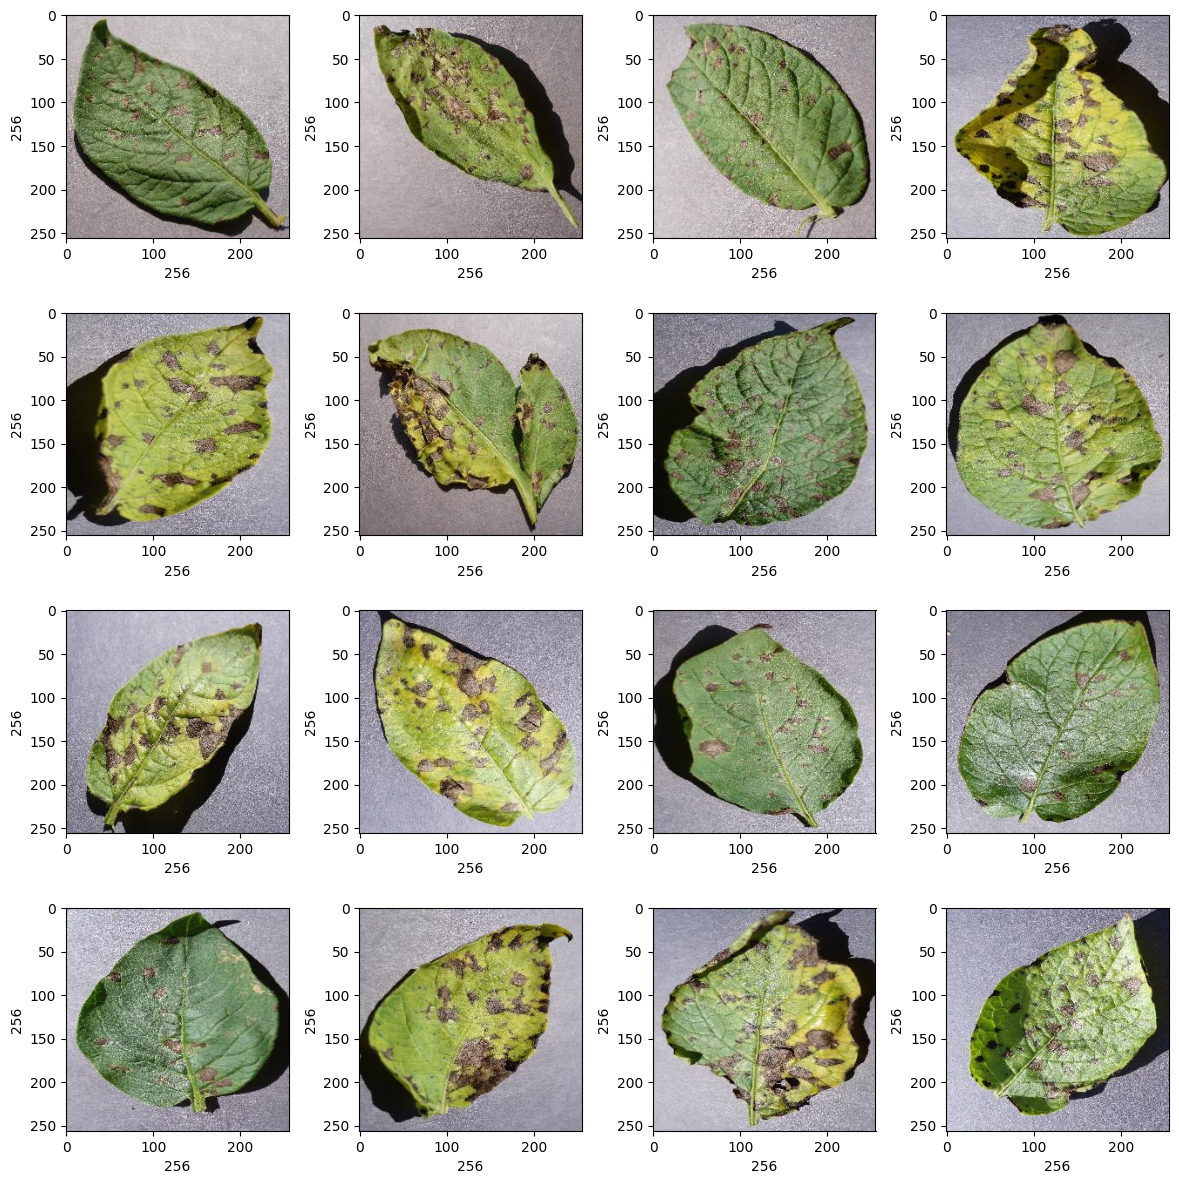

In [ ]:
plt.figure(figsize=(12,12))
path = "/content/drive/MyDrive/Datasets/MyDatasets/PlantVillage/Potato___Early_blight"
for i in range(1,17):
  plt.subplot(4,4,i)
  plt.tight_layout()
  rand_img = imread(path +'/'+ random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize = 10)
  plt.ylabel(rand_img.shape[0], fontsize = 10)

In [ ]:
import os
print(os.listdir("/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Potato___healthy', 'Tomato_Late_blight', 'Tomato_Early_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
#Coverting Images to array
def convert_image_to_array(image_dir):
  try:
    image = cv2.imread(image_dir)
    if image is not None:
      image = cv2.resize(image,(256,256))
      return img_to_array(image)
    else :
      return np.array([])
  except Exception as e:
    print(f"Error : {e}")
    return None

In [ ]:
dir = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"
image_list, label_list = [], []
all_labels = ['Tomato_Bacterial_spot', 'Potato___Early_blight', 'Tomato_healthy']
binary_labels = [0,1,2]
temp = -1
#Reading and converty image to numpy array
for directory in ['Tomato_Bacterial_spot', 'Potato___Early_blight', 'Tomato_healthy']:
  plant_image_list = listdir(f"{dir}/{directory}")
  temp += 1
  for files  in plant_image_list:
    image_path = f"{dir}/{directory}/{files}"
    image_list.append(convert_image_to_array(image_path))
    label_list.append(binary_labels[temp])

In [ ]:
#Visualize the number of classes count
label_counts = pd.DataFrame(label_list).value_counts()
label_counts.head()

,count
0,
0,2127
2,1591
1,1000


In [ ]:
image_list[0].shape

(256, 256, 3)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state=10)


In [ ]:
x_train = np.array(x_train, dtype=np.float16) / 255.0
x_test = np.array(x_test, dtype=np.float16) / 225.0
x_train = x_train.reshape(-1,256,256,3)
x_test = x_test.reshape(-1,256,256,3)

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3,3), padding="same", input_shape=(256,256,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(3,3)))
model.add(Conv2D(16, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 85, 85, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 42, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │       225,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,347 (903.70 KB)

 Trainable params: 231,347 (903.70 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer= Adam(0.0001),metrics=['accuracy'])


In [ ]:
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=10)


In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), padding="same", input_shape=(256,256,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(3,3)))
model.add(Conv2D(16, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64, activation="relu"))  # increased neurons for better learning
model.add(Dense(15, activation="softmax"))  # 15 classes instead of 3

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(0.0001),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 85, 85, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 42, 42, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,806,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,812,895 (6.92 MB)

 Trainable params: 1,812,895 (6.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# create data generator with rescaling
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# training set
train_generator = datagen.flow_from_directory(
    "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage",
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

# validation set
val_generator = datagen.flow_from_directory(
    "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage",
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

# fit model using generator
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)



Found 16153 images belonging to 15 classes.
Found 4031 images belonging to 15 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1010/1010 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3629 - loss: 2.0710

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert RGB → Gray
    transforms.Resize((64, 64)),                # Resize all images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])   # Normalize (gray has 1 mean/std)
])

In [ ]:
data_path = "/content/drive/MyDrive/Datasets/MyDatasets/PlantVillage"

In [ ]:
dataset = datasets.ImageFolder(root=data_path, transform=transform_gray)

# Split dataset (80% train, 20% val)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", dataset.classes)  # Check labels

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)   # smaller now
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
from torch.utils.data import random_split

small_train, _ = random_split(train_dataset, [2000, len(train_dataset)-2000])
train_loader = DataLoader(small_train, batch_size=32, shuffle=True)


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cpu


In [ ]:
transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # 1 channel for gray
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)       # depends on image size
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cpu


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Config: choose RGB or Gray
use_gray = True   # set False if you want RGB

if use_gray:
    channels = 1
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),   # now 128×128
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
else:
    channels = 3
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

# Dataset
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"
dataset = datasets.ImageFolder(root=data_path, transform=transform)

subset_size = min(2000, len(dataset))  # keep small for quick runs
train_size = int(0.8 * subset_size)
val_size   = subset_size - train_size
small_dataset, _ = random_split(dataset, [subset_size, len(dataset)-subset_size])
train_dataset, val_dataset = random_split(small_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", dataset.classes)

# CNN for 128×128
class SmallCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # 128 -> 64 -> 32 after 2 poolings
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 128→64
        x = self.pool(self.relu(self.conv2(x)))   # 64→32
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Training loop
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on:", device)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.2f}%, "
              f"Val Acc: {val_acc:.2f}%")

# Run training
num_classes = len(dataset.classes)
model = SmallCNN(num_classes=num_classes, in_channels=channels)
train_model(model, train_loader, val_loader, epochs=10)

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Training on: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/10] Train Acc: 24.62%, Val Acc: 41.75%
Epoch [2/10] Train Acc: 45.00%, Val Acc: 45.75%
Epoch [3/10] Train Acc: 54.12%, Val Acc: 52.50%
Epoch [4/10] Train Acc: 65.00%, Val Acc: 52.75%
Epoch [5/10] Train Acc: 71.88%, Val Acc: 56.50%
Epoch [6/10] Train Acc: 80.38%, Val Acc: 55.25%
Epoch [7/10] Train Acc: 86.69%, Val Acc: 57.75%
Epoch [8/10] Train Acc: 89.88%, Val Acc: 59.50%
Epoch [9/10] Train Acc: 93.38%, Val Acc: 57.50%
Epoch [10/10] Train Acc: 94.81%, Val Acc: 57.50%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Config: choose RGB or Gray
use_gray = True   # set False if you want RGB

if use_gray:
    channels = 1
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),   # now 128×128
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
else:
    channels = 3
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

# Dataset
data_path = "/content/drive/My Drive/Datasets/MyDatasets/PlantVillage"
dataset = datasets.ImageFolder(root=data_path, transform=transform)

subset_size = min(2000, len(dataset))  # keep small for quick runs
train_size = int(0.8 * subset_size)
val_size   = subset_size - train_size
small_dataset, _ = random_split(dataset, [subset_size, len(dataset)-subset_size])
train_dataset, val_dataset = random_split(small_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", dataset.classes)

# CNN for 128×128
class SmallCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # 128 -> 64 -> 32 after 2 poolings
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 128→64
        x = self.pool(self.relu(self.conv2(x)))   # 64→32
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Training loop
def train_model(model, train_loader, val_loader, epochs=5, lr=0.001):
    # auto detect cuda
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on:", device)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.2f}%, "
              f"Val Acc: {val_acc:.2f}%")

# Run training
num_classes = len(dataset.classes)
model = SmallCNN(num_classes=num_classes, in_channels=channels)
train_model(model, train_loader, val_loader, epochs=5)


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Training on: cpu
Epoch [1/5] Train Acc: 18.94%, Val Acc: 29.50%
Epoch [2/5] Train Acc: 36.94%, Val Acc: 42.25%
Epoch [3/5] Train Acc: 43.69%, Val Acc: 47.25%
Epoch [4/5] Train Acc: 53.38%, Val Acc: 52.75%
Epoch [5/5] Train Acc: 58.69%, Val Acc: 52.50%


In [ ]:
# Save the trained model
save_path = "plant_cnn.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Load model later
# To reload, create the same model architecture first:
loaded_model = SmallCNN(num_classes=num_classes, in_channels=channels)
loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()  # set to evaluation mode
print("Model loaded successfully.")

Model saved to plant_cnn.pth
Model loaded successfully.
